In [3]:
from openai import OpenAI
from pydantic import BaseModel

In [4]:
from dotenv import load_dotenv

In [127]:
import os
import re
import json
from pathlib import Path
import base64
import mimetypes
from glob import glob
from typing import List
import hashlib
import subprocess
import shutil

In [41]:
import requests
from devtools import pprint, PrettyFormat

In [6]:
import docker

In [115]:
from moviepy import VideoFileClip, AudioFileClip, ImageClip, concatenate_videoclips

In [8]:
from IPython.display import Image
from IPython.display import Audio

In [9]:
from elevenlabs import ElevenLabs

In [39]:
from dataclasses import dataclass

In [95]:
from pydub import AudioSegment

In [10]:
pp = PrettyFormat()

In [11]:
load_dotenv()

True

In [12]:
llm_client = OpenAI()

In [14]:
docker_client = docker.from_env()

### Utility functions

In [15]:
def image_to_data_url(path: str | Path) -> str:
    path = Path(path).expanduser().resolve()

    mime_type, _ = mimetypes.guess_type(path)
    if mime_type is None:
        mime_type = "application/octet-stream"

    image_bytes = path.read_bytes()

    b64_encoded = base64.b64encode(image_bytes).decode("ascii")

    return f"data:{mime_type};base64,{b64_encoded}"

In [16]:
image_dataset = glob('dataset/images/**/*.png')

## 00. Clean up previous run

In [128]:
shutil.rmtree("audio")
shutil.rmtree("output")
shutil.rmtree("manim")

## 01. Context gathering

In [17]:
problem_image = sorted(image_dataset)[22]

In [18]:
problem_image

'dataset/images/mathematical_methods/ch4q4.png'

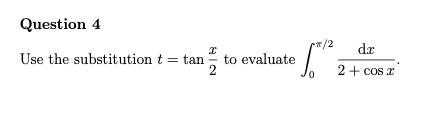

In [19]:
Image(problem_image)

## 02. Problem extraction

In [365]:
class Equations(BaseModel):
    latext: str
    unicode: str

class Prerequisites(BaseModel):
    topic: str
    reason: str

class Givens(BaseModel):
    known_facts: str
    explanation: str

class ProblemAnalysis(BaseModel):
    equations: list[Equations]
    problem_description: str
    prerequisites: list[Prerequisites]
    givens: list[Givens]

In [367]:
response = llm_client.responses.parse(
    model="o3",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": "Extract the equations, description of the maths problem, prerequisite required knowledge and known 'givens' in the problem which are helpful in answering the question."},
            {
                "type": "input_image",
                "image_url": image_to_data_url(problem_image)
            },
        ],
    }],
    text_format=ProblemAnalysis
)

In [368]:
problem_analysis = response.output_parsed

In [369]:
pprint(problem_analysis.equations[0])

Equations(
    latext='\\displaystyle \\int_{0}^{\\pi/2} \\frac{\\mathrm dx}{2+\\cos x}',
    unicode='∫₀^{π/2} dx⁄(2 + cos x)',
)


In [370]:
pprint(problem_analysis)

ProblemAnalysis(
    equations=[
        Equations(
            latext='\\displaystyle \\int_{0}^{\\pi/2} \\frac{\\mathrm dx}{2+\\cos x}',
            unicode='∫₀^{π/2} dx⁄(2 + cos x)',
        ),
        Equations(
            latext='t=\\tan\\frac{x}{2}',
            unicode='t = tan(x⁄2)',
        ),
        Equations(
            latext='dx = \\frac{2\\,dt}{1+t^{2}}',
            unicode='dx = 2 dt ⁄ (1+t²)',
        ),
        Equations(
            latext='\\cos x = \\frac{1-t^{2}}{1+t^{2}}',
            unicode='cos x = (1−t²) ⁄ (1+t²)',
        ),
    ],
    problem_description='Evaluate the definite integral ∫₀^{π⁄2} 1⁄(2+cos x) dx by making the substitution t = tan(x⁄2).',
    prerequisites=[
        Prerequisites(
            topic='Integral calculus – substitution method',
            reason='Needed to change variables from x to t and transform the differential and limits.',
        ),
        Prerequisites(
            topic='Tangent half–angle identities',
            rea

## 03. Solution solving steps

In [371]:
class ProblemSolvingStep(BaseModel):
    title: str
    description: str
    hints: str

class Solution(BaseModel):
    steps: list[ProblemSolvingStep]
    final_solution: str

In [373]:
solution_step_prompt = f"""Solve this problem step-by-step:

{problem_analysis.problem_description}

Relevant LaTeX equation:

""" + '\n'.join([e.latext for e in problem_analysis.equations])

In [374]:
print(solution_step_prompt)

Solve this problem step-by-step:

Evaluate the definite integral ∫₀^{π⁄2} 1⁄(2+cos x) dx by making the substitution t = tan(x⁄2).

Relevant LaTeX equation:

\displaystyle \int_{0}^{\pi/2} \frac{\mathrm dx}{2+\cos x}
t=\tan\frac{x}{2}
dx = \frac{2\,dt}{1+t^{2}}
\cos x = \frac{1-t^{2}}{1+t^{2}}


In [376]:
problem_response = llm_client.responses.parse(
    model="o3",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": solution_step_prompt},
        ],
    }],
    text_format=Solution
)

In [377]:
pprint(problem_response.output_parsed.steps)

[
    ProblemSolvingStep(
        title='1. Introduce the Weierstrass substitution',
        description=(
            'Let  t = tan(x/2).  For this change of variables we have\n'
            ' dx = 2 dt /(1+t^2) and  cos x = (1-t^2)/(1+t^2).'
        ),
        hints='Remember the standard identities for the tangent half–angle substitution.',
    ),
    ProblemSolvingStep(
        title='2. Transform the limits of integration',
        description=(
            'When x = 0 ⇒ t = tan(0) = 0.\n'
            'When x = π/2 ⇒ t = tan(π/4) = 1.'
        ),
        hints='Compute t at both endpoints.',
    ),
    ProblemSolvingStep(
        title='3. Rewrite the integral in terms of t',
        description=(
            'I = ∫₀^{π/2} dx/(2+cos x)\n'
            '   = ∫₀^{1} [ 2 dt /(1+t^2) ] / [ 2 + (1-t^2)/(1+t^2) ].'
        ),
        hints='Insert the expressions for dx and cos x and keep the fraction clear.',
    ),
    ProblemSolvingStep(
        title='4. Simplify the integrand',
    

## 04. Gotchas

In [378]:
# TODO

Intention for this workflow is to analyse each ProblemSolvingStep and determine if there are any common mistakes learners may make when approaching this problem.

## 05. Verify solution correctness

In [379]:
# TODO using Sympy

#### Example of generated sympy script for validating solution correctness

This is using one of the fixture examples of an Integration problem

In [380]:
from sympy import (
    Symbol,
    integrate,
    diff,
    simplify,
    lambdify,
    log,
    pretty,
)

In [381]:
x = Symbol("x", real=True)
integrand = x**2 / (x**2 - 1)

antiderivative = integrate(integrand, x)

# SymPy’s default form is  x + log(x - 1)/2 - log(x + 1)/2 .
# A prettier compact version uses log((x - 1)/(x + 1)):
antiderivative = simplify(antiderivative)  # triggers the log-difference identity

print("Computed antiderivative F(x):\n")
print(pretty(antiderivative))

Computed antiderivative F(x):

    log(x - 1)   log(x + 1)
x + ────────── - ──────────
        2            2     


In [382]:
# ----------------------------------------------------------------------
# Symbolic verification  F'(x) == integrand
# ----------------------------------------------------------------------
sym_diff = diff(antiderivative, x)
sym_check = simplify(sym_diff - integrand)

In [383]:
print(pretty(sym_diff))

        1           1    
1 - ───────── + ─────────
    2⋅(x + 1)   2⋅(x - 1)


In [384]:
print("Difference after simplification: " + str(sym_check))

Difference after simplification: 0


## 06. Manim generation

In [385]:
manim_prompt = """
You are an expert Manim-CE animator and math instructor.

**Task**  
Write a single Python script called **`solve_problem.py`** (Manim CE ≥ 0.18).  
The script must define **one Scene class per solution step** so that each scene can be rendered separately:

| Scene class | Corresponds to | Render command example |
|-------------|----------------|------------------------|
""" + "\n".join(
        [
            f"| `Step{idx+1}(Scene) | '{step.title}' | `manim -pqh solve_problem.py Step{idx+1} -o step_{idx+1}` |" 
            for idx, step in enumerate(problem_response.output_parsed.steps)
        ]
    ) + """

**For *each* scene**  
1. Use a dark background (`BACKGROUND_COLOR = "#1e1e1e"`).  
2. Display the step title in a banner at the top (semi-transparent `BLUE_E`).  
3. Show and animate the LaTeX equations with `MathTex`; highlight changes (`YELLOW`, `ORANGE`).  
4. Keep ~0.5 s waits between minor animations, ~1 s between major ones.  
5. Finish the scene with a short pause (0.5 s) so the last frame isn’t cut off.

**Global visual style**  
- Text `WHITE`, titles 48 pt, equations 36 pt.  
- Use `FadeIn`, `Transform`, `Circumscribe`, and mild `LaggedStart`.  
- No audio handling — narration will be added later.

**Input data (do not alter)**  

```python
"""+pp(problem_analysis)+"""

"""+pp(problem_response.output_parsed)+"""
```

Output
Return only the contents of solve_problem.py—no extra comments—so each scene can be rendered like:

```bash
manim -pqh solve_problem.py Step1 -o step_1
manim -pqh solve_problem.py Step2 -o step_2
...
```

Constraints

Wrap repeated UI elements (title banner, highlight routine) in helper functions.

Ensure each scene renders at -pqh quality in ≤ 90 s on a modest laptop.
"""


In [386]:
print(manim_prompt)


You are an expert Manim-CE animator and math instructor.

**Task**  
Write a single Python script called **`solve_problem.py`** (Manim CE ≥ 0.18).  
The script must define **one Scene class per solution step** so that each scene can be rendered separately:

| Scene class | Corresponds to | Render command example |
|-------------|----------------|------------------------|
| `Step1(Scene) | '1. Introduce the Weierstrass substitution' | `manim -pqh solve_problem.py Step1 -o step_1` |
| `Step2(Scene) | '2. Transform the limits of integration' | `manim -pqh solve_problem.py Step2 -o step_2` |
| `Step3(Scene) | '3. Rewrite the integral in terms of t' | `manim -pqh solve_problem.py Step3 -o step_3` |
| `Step4(Scene) | '4. Simplify the integrand' | `manim -pqh solve_problem.py Step4 -o step_4` |
| `Step5(Scene) | '5. Integrate' | `manim -pqh solve_problem.py Step5 -o step_5` |
| `Step6(Scene) | '6. Apply the limits' | `manim -pqh solve_problem.py Step6 -o step_6` |

**For *each* scene**  
1. 

In [393]:
manim_script = llm_client.responses.create(
    model="o3",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": manim_prompt},
        ],
    }],
)

In [394]:
pprint(manim_script.output[1].content[0].text)

(
    '```python\n'
    '# solve_problem.py\n'
    'from manim import *\n'
    '\n'
    '# ----------------------------  GLOBAL STYLE  ---------------------------- #\n'
    'BACKGROUND_COLOR = "#1e1e1e"\n'
    'TITLE_COLOR = BLUE_E\n'
    'TEXT_COLOR = WHITE\n'
    'HIGHLIGHT_1 = YELLOW\n'
    'HIGHLIGHT_2 = ORANGE\n'
    'TITLE_SIZE = 48\n'
    'EQN_SIZE = 36\n'
    '\n'
    'config.background_color = BACKGROUND_COLOR\n'
    '\n'
    '\n'
    '# ---------------------------  HELPER FUNCTIONS  -------------------------- #\n'
    'def make_banner(title: str) -> VGroup:\n'
    '    """Return a semi-transparent banner with the given title."""\n'
    '    banner_rect = Rectangle(\n'
    '        width=config.frame_width,\n'
    '        height=0.9,\n'
    '        stroke_width=0,\n'
    '        fill_color=TITLE_COLOR,\n'
    '        fill_opacity=0.45,\n'
    '    ).to_edge(UP)\n'
    '    banner_text = Text(title, font_size=TITLE_SIZE, color=TEXT_COLOR).move_to(\n'
    '        banner_rec

In [395]:
# Cleaning markdown backticks (```python ... ```) from first and last lines
cleaned_manim_script = '\n'.join(manim_script.output[1].content[0].text.split('\n')[1:-1])

### Warning!

<span style="color: red">Do not run arbitrary Python scripts generated by LLMs without checking it first!</span>

Inspect its contents and run in an isolated environment, like a Docker container.

In [396]:
# Use docker to execute Manim for each individual script

In [415]:
host_dir = Path.cwd() / "manim"

In [414]:
os.makedirs(host_dir, exist_ok=True)
with open('manim/solve_problem.py', 'w') as f:
    f.write(cleaned_manim_script)

In [416]:
volumes = {
    str(host_dir.resolve()): {
        "bind": "/manim",
        "mode": "rw",
    }
}

In [423]:
for idx, step in enumerate(problem_response.output_parsed.steps):
    container = docker_client.containers.run(
        image="manimcommunity/manim",
        command=f"manim -pqh solve_problem.py Step{idx+1} -o step_{idx+1}",
        working_dir="/manim",
        volumes=volumes,
        tty=True,
        stdin_open=True,
        auto_remove=True,
        detach=True
    )

    result = container.wait()
    print("Exit code:", result.get("StatusCode", "unknown"))

Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1


In [418]:
# It errors with exit code 1 but still produces the videos successfully. To investigate.

In [424]:
video_step_files = glob("manim/media/videos/solve_problem/1080p60/*.mp4")

In [430]:
video_step_files

['manim/media/videos/solve_problem/1080p60/step_6.mp4',
 'manim/media/videos/solve_problem/1080p60/step_4.mp4',
 'manim/media/videos/solve_problem/1080p60/step_5.mp4',
 'manim/media/videos/solve_problem/1080p60/step_1.mp4',
 'manim/media/videos/solve_problem/1080p60/step_2.mp4',
 'manim/media/videos/solve_problem/1080p60/step_3.mp4']

In [427]:
# Get the last frame of each slide to build up the script

In [431]:
def extract_last_frame(video, out_png=None):
    video = pathlib.Path(video)
    if out_png is None:
        out_png = video.with_suffix(".last.png")

    probe_cmd = [
        "ffprobe", "-v", "error",
        "-select_streams", "v:0",
        "-count_frames",
        "-show_entries", "stream=nb_read_frames",
        "-print_format", "json",
        str(video)
    ]
    nb_frames = int(json.loads(subprocess.check_output(probe_cmd))
                    ["streams"][0]["nb_read_frames"])

    select_filter = f"select=eq(n\\,{nb_frames-1})"
    ff_cmd = [
        "ffmpeg", "-hide_banner", "-loglevel", "error", "-y",
        "-i", str(video),
        "-vf", select_filter,
        "-vframes", "1",
        str(out_png)
    ]
    subprocess.run(ff_cmd, check=True)
    return pathlib.Path(out_png)


videos = sorted(pathlib.Path("manim/media/videos/solve_problem/1080p60").glob("step_*.mp4"))
for v in videos:
    png = extract_last_frame(v)
    print("✓", png)

✓ manim/media/videos/solve_problem/1080p60/step_1.last.png
✓ manim/media/videos/solve_problem/1080p60/step_2.last.png
✓ manim/media/videos/solve_problem/1080p60/step_3.last.png
✓ manim/media/videos/solve_problem/1080p60/step_4.last.png
✓ manim/media/videos/solve_problem/1080p60/step_5.last.png
✓ manim/media/videos/solve_problem/1080p60/step_6.last.png


## 07. Script dialogue generation

In [432]:
dia_prompt = """
You are a dialogue-designer for the **Dia** text-to-speech model.

**Goal**  
For every problem-solving *step* in `Solution.steps`, write a short, engaging
conversation between two speakers:

| Tag | Persona | Role |
|-----|---------|------|
| `[S1]` | Teacher | Guides, prompts, confirms |
| `[S2]` | Student | Thinks aloud, attempts answers |

Each chat must match its **corresponding slide image** (the final
frame of that step’s video).

**Conversation rules**

1. **Length** – 4 – 6 utterances total (≈ 70 words).  
2. **Tone** – friendly, notebook-style “chalk & talk”.  
3. **Slide awareness** – Refer to what’s *visible* (symbols, highlights,
   colours) without restating the full equation.  
4. **Pedagogical arc** –  
   * Teacher poses a micro-question → Student responds → Teacher affirms
     or corrects → Teacher wraps up the step.  
5. **Dia pronunciation constraint** –  
   Dia cannot voice raw math symbols or Unicode. **Spell everything out:**

   | Symbol | Speak as… |
   |--------|-----------|
   | `x²`   | “x squared” |
   | `/`    | “divided by” |
   | `∫`    | “integral of” |
   | `→`    | “implies” |
   | `ln`   | “natural log” |

   *Never include LaTeX, Unicode superscripts, or subscripts directly in
   the dialogue.*  
6. **Optional flavour tags** – Use sparingly at natural points in the conversation.  
   `(laughs) (sighs) (gasps) …` *(full list provided below)*  
7. **No extra stage directions** beyond the allowed tag.

**Allowed tags**  

```
(laughs) (clears throat) (sighs) (gasps) (coughs) (singing) (sings) (mumbles) (beep) (groans) (sniffs) (claps) (screams) (inhales) (exhales) (applause) (burps) (humming) (sneezes) (chuckle) (whistles)
```


Do not merge steps; keep chats in original order.

─────────────────── EXAMPLE (abridged) ───────────────────

Step 2 – Partial Fractions
[S1] See the two factors in the denominator?
[S2] Yep—(x − 1) and (x + 1). Should we split the fraction next?
[S1] Exactly. What constants go on top?
[S2] I’m guessing A over (x − 1) and B over (x + 1).
[S1] Good guess—and with x = 1 you’ll find A = ½. Keep going! (chuckle) 
────────────────────────────────────────────────────────────────────────


Input data:

```python
"""+pp(problem_analysis)+"""

"""+pp(problem_response.output_parsed)+"""
```
"""

In [433]:
s1_personality = "Calm, encouraging, mid-pitch, steady pace. Male Australian podcaster style voice who can smash out the news with a dash of sardonic humour and irony."
s2_personality = "Curious, light, slightly faster, upbeat. Female natural voice with umms, errs and hesitations. Friendly and sometimes a little sarcastic with light humour."

In [443]:
elevenlabs_prompt = r"""
You are designing **dialogue scripts** that will be rendered with the
**ElevenLabs Text-to-Speech API** (multi-voice).  
Two distinct voices will be used:

| Tag | Persona | Voice-ID (placeholder) | Personality cues |
|-----|---------|------------------------|------------------|
| `[S1]` | Teacher | `<VOICE_ID_TEACHER>` | """+s1_personality+""" |
| `[S2]` | Student | `<VOICE_ID_STUDENT>` | """+s2_personality+""" |

(Our orchestration layer will swap the placeholders for real voice IDs
before calling ElevenLabs.)

───────────────────────────
Conversation specification
───────────────────────────
For **each problem-solving step** in `Solution.steps`, generate a short,
self-contained chat that matches the final slide frame for that step.

1. **Length** 10 – 20 utterances total, focusing on being an engaging conversation to drive understanding.
2. **Tone** friendly “chalk & talk”; S1 guides, S2 thinks aloud. Add colour and personality to the conversation with liberal use metaphors.
3. **Slide awareness** Mention highlights or colours *briefly*; do **not**
   restate the full equation.
4. **Pedagogical arc** S1 → question → S2 reply → S1 confirm/correct → S2 cements understanding → S1 encourages and celebrates → wrap-up.  
5. **Pronunciation control** ElevenLabs mispronounces raw math
   symbols; **spell them out**:

   | Symbol | Say … |
   |--------|-------|
   | `x²`   | “x squared” |
   | `/`    | “divided by” |
   | `∫`    | “integral of” |
   | `→`    | “implies” |
   | `ln`   | “natural log” |

   *Never* include LaTeX, superscripts or subscripts directly.
6. **No extra stage directions** beyond the allowed tag.  
7. **Order** Do **not** merge steps; output chats in the same order as
   `Solution.steps`.

──────────────────────────────
Example (abridged, symbol-safe)
──────────────────────────────
Step 2 – Partial Fractions  
[S1] Notice the denominator—see “x minus one” times “x plus one”?  
[S2] Yes! That means we can split the fraction, right?  
[S1] Exactly. What constants should we place on top?  
[S2] Let me guess: A over “x minus one” and B over “x plus one.”  
[S1] Good. Plugging in x equals one gives A equals one-half—keep going!

────────────────────────────────────────────────────────────
**Input data**

```python
""" + pp(problem_analysis) + """

""" + pp(problem_response.output_parsed) + """
"""

In [444]:
base64_slide_images = [{"type": "input_image", "image_url": image_to_data_url(i)} for i in glob("manim/media/videos/solve_problem/1080p60/*.last.png")]

In [445]:
# script_collected_prompt = [{ "type": "input_text", "text": dia_prompt }] + base64_slide_images
script_collected_prompt = [{ "type": "input_text", "text": elevenlabs_prompt }] + base64_slide_images

In [446]:
class StepConversation(BaseModel):
    step: str
    script: str

class ConversationScript(BaseModel):
    steps: list[StepConversation]

In [448]:
script_response = llm_client.responses.parse(
    model="o3",
    input=[{
        "role": "user",
        "content": script_collected_prompt,
    }],
    text_format=ConversationScript
)

In [449]:
pprint(script_response.output_parsed)

ConversationScript(
    step=[
        StepConversation(
            step='1. Introduce the Weierstrass substitution',
            script=(
                '[S1] Alright, see that slick yellow "t equals tan of x over two" in the middle of the slide?\n'
                '[S2] Yup, it’s flashing at me like a neon sign. That’s our new variable, right?\n'
                '[S1] Exactly. It’s the Weierstrass swap—turns every trig bump into a tidy rational road.\n'
                '[S2] So the differential changes too. Umm… dx becomes, err, two dt divided by one plus t squared?\n'
                '[S1] Nailed it, first go! And check the white line underneath—cos x morphs into one minus t squared o'
                'ver one plus t squared.\n'
                '[S2] Oh, that’s the classic identity! Feels like putting on comfy old slippers.\n'
                '[S1] Question time: why do we love this substitution for integrals with sine or cosine in the basemen'
                't?\n'
             

In [450]:
conversation_script = script_response.output_parsed

In [458]:
conversation_script.steps[0].script

'[S1] Alright, see that slick yellow "t equals tan of x over two" in the middle of the slide?\n[S2] Yup, it’s flashing at me like a neon sign. That’s our new variable, right?\n[S1] Exactly. It’s the Weierstrass swap—turns every trig bump into a tidy rational road.\n[S2] So the differential changes too. Umm… dx becomes, err, two dt divided by one plus t squared?\n[S1] Nailed it, first go! And check the white line underneath—cos x morphs into one minus t squared over one plus t squared.\n[S2] Oh, that’s the classic identity! Feels like putting on comfy old slippers.\n[S1] Question time: why do we love this substitution for integrals with sine or cosine in the basement?\n[S2] Because fractions with trig are messy. Turning them into algebraic fractions is like translating slang into plain English—much easier to integrate.\n[S1] Bang on. Any worries about domain or sign changes for this problem?\n[S2] Since x runs from zero to pi divided by two, tan of x over two is non-negative, so t behav

In [ ]:
# model dump json script

# 08. Text to Speech

In [459]:
os.makedirs("audio", exist_ok=True)

### Dia voice generation (commented out)

In [460]:
def query_dia(payload):
    response = requests.post("https://router.huggingface.co/fal-ai/fal-ai/dia-tts", headers={
        "Authorization": f"Bearer {os.environ['HF_TOKEN']}",
    }, json=payload)
    return response.json()

In [461]:
# for idx, slide in enumerate(conversation_script.slides):
#     print("Generating conversation")
#     audio_result = query_dia({
#        "text": slide.conversation
#     })
#     print("Preparing to download")
#     local_filename = f"audio/step_{idx+1}.wav"
#     with requests.get(audio_result['audio']['url'], stream=True, timeout=15) as r:
#         r.raise_for_status()
#         with open(local_filename, "wb") as f:
#             for chunk in r.iter_content(chunk_size=64 * 1024):
#                 if chunk:
#                     f.write(chunk)
#     print(f"Local file {local_filename} saved")

### ElevenLabs voice generation

In [20]:
elevenlabs_client = ElevenLabs(
    api_key=os.environ["ELEVENLABS_API_KEY"]
)

In [21]:
ELEVENLABS_MODEL_NAME = 'eleven_multilingual_v2'

In [65]:
# ─────────────────────────────────────────────────────────────
# helper: deterministic cache filename  (voice│text → hash)
# ─────────────────────────────────────────────────────────────
def cache_path(step_idx: str, role: str, text: str, voice_id: str) -> Path:
    h = hashlib.sha256(f"{voice_id}|{text}".encode()).hexdigest()[:16]
    return Path("audio") / f"step_{step_idx}_{role}_{h}.wav"

In [92]:
# ─────────────────────────────────────────────────────────────
# temporarily use the script.json to set up the result
# ─────────────────────────────────────────────────────────────
steps_json = json.loads(open('script.json', 'r').read())

@dataclass
class StepConversationObj:
    step: str = None
    script: str = None
    

@dataclass
class ConversationScriptObj:
    steps: List[StepConversationObj]



steps = ConversationScriptObj(steps=[StepConversationObj(**s) for s in steps_json['steps']])

In [88]:
steps.steps[0].script

'[S1] Alright, see that slick yellow "t equals tan of x over two" in the middle of the slide?\n[S2] Yup, it’s flashing at me like a neon sign. That’s our new variable, right?\n[S1] Exactly. It’s the Weierstrass swap—turns every trig bump into a tidy rational road.\n[S2] So the differential changes too. Umm… dx becomes, err, two dt divided by one plus t squared?\n[S1] Nailed it, first go! And check the white line underneath—cos x morphs into one minus t squared over one plus t squared.\n[S2] Oh, that’s the classic identity! Feels like putting on comfy old slippers.\n[S1] Question time: why do we love this substitution for integrals with sine or cosine in the basement?\n[S2] Because fractions with trig are messy. Turning them into algebraic fractions is like translating slang into plain English—much easier to integrate.\n[S1] Bang on. Any worries about domain or sign changes for this problem?\n[S2] Since x runs from zero to pi divided by two, tan of x over two is non-negative, so t behav

In [90]:
steps.steps[0].script.split("\n")

['[S1] Alright, see that slick yellow "t equals tan of x over two" in the middle of the slide?',
 '[S2] Yup, it’s flashing at me like a neon sign. That’s our new variable, right?',
 '[S1] Exactly. It’s the Weierstrass swap—turns every trig bump into a tidy rational road.',
 '[S2] So the differential changes too. Umm… dx becomes, err, two dt divided by one plus t squared?',
 '[S1] Nailed it, first go! And check the white line underneath—cos x morphs into one minus t squared over one plus t squared.',
 '[S2] Oh, that’s the classic identity! Feels like putting on comfy old slippers.',
 '[S1] Question time: why do we love this substitution for integrals with sine or cosine in the basement?',
 '[S2] Because fractions with trig are messy. Turning them into algebraic fractions is like translating slang into plain English—much easier to integrate.',
 '[S1] Bang on. Any worries about domain or sign changes for this problem?',
 '[S2] Since x runs from zero to pi divided by two, tan of x over two

In [99]:
voice_map = json.loads(Path("voices.json").read_text())

for step_idx, step in enumerate(steps.steps):
    print(f"\n🎬  === Step {step_idx+1} ===")
    prev_request_ids: list[str] = []

    speaker_turns = step.script.split("\n")
    speaker_turn_count = len(speaker_turns)
    step_wav_files = []

    for turn_idx, turn in enumerate(speaker_turns):
        role, text = turn[0:4], turn[5:]
        print(f"Role: {role}")
        print(f"Text: {text}")

        voice_id = voice_map[role]

       
        wav_path = cache_path(step_idx, role, turn, voice_id)
        if wav_path.exists():
            step_wav_files.append(wav_path)
            print(f"↪︎  cache hit  {wav_path.name}")
            continue

        # prepare context fields
        prev_text = None if turn_idx == 0 else " ".join(speaker_turns[:turn_idx])
        next_text = None if turn_idx == speaker_turn_count - 1 else " ".join(speaker_turns[turn_idx + 1 :])

        # call ElevenLabs via SDK
        audio_bytes = elevenlabs_client.text_to_speech.convert(
            text           = text,
            voice_id       = voice_id,
            model_id       = ELEVENLABS_MODEL_NAME,
            voice_settings = {
                "speed": 1.2,
                #"use_speaker_boost": True,
                "style": 0.5,
                #"similarity_boost": 0.7,
                "stability": 0.2
            },
            # context
            previous_text            = prev_text,
            next_text                = next_text,
            previous_request_ids     = prev_request_ids[-3:],
            # true to see if normalization will also enhance pronunciation
            apply_text_normalization = 'on'
        )

        with open(wav_path, 'wb') as f:
            audio = b"".join(audio_bytes)
            f.write(audio)
        
        req_id = elevenlabs_client.history.get_all().history[0].request_id
        if req_id:
            prev_request_ids.append(req_id)

        step_wav_files.append(wav_path)
        print(f"✓  {wav_path.name}   req_id={req_id}")
    
    # combine all step_wav_files files
    # -----------------------------------------------------------
    if step_wav_files:
        combined = AudioSegment.from_file(step_wav_files[0])
        for extra in step_wav_files[1:]:
            combined += AudioSegment.from_file(extra)

        out_slide = Path("audio") / "combined" / f"step_{step_idx+1}.wav"
        out_slide.parent.mkdir(parents=True, exist_ok=True)
        combined.export(out_slide, format="wav")
        print("🔊  wrote", out_slide.name)


🎬  === Step 1 ===
Role: [S1]
Text: Alright, see that slick yellow "t equals tan of x over two" in the middle of the slide?
↪︎  cache hit  step_0_[S1]_d74454bdb5778b7c.wav
Role: [S2]
Text: Yup, it’s flashing at me like a neon sign. That’s our new variable, right?
↪︎  cache hit  step_0_[S2]_9d971b76f71d19ad.wav
Role: [S1]
Text: Exactly. It’s the Weierstrass swap—turns every trig bump into a tidy rational road.
↪︎  cache hit  step_0_[S1]_3c56f7a3c21b9e59.wav
Role: [S2]
Text: So the differential changes too. Umm… dx becomes, err, two dt divided by one plus t squared?
↪︎  cache hit  step_0_[S2]_11e255f34b495fb7.wav
Role: [S1]
Text: Nailed it, first go! And check the white line underneath—cos x morphs into one minus t squared over one plus t squared.
↪︎  cache hit  step_0_[S1]_7f3c4907d97c2912.wav
Role: [S2]
Text: Oh, that’s the classic identity! Feels like putting on comfy old slippers.
↪︎  cache hit  step_0_[S2]_0b72e2cb8844abd2.wav
Role: [S1]
Text: Question time: why do we love this subs

In [ ]:
## Debugging can use Audio from IPython
# Audio(audio)

# 09. ffmpeg stitching video and audio together

In [107]:
step_videos_glob   = "manim/media/videos/solve_problem/1080p60/step_*.mp4"
still_image_glob   = "manim/media/videos/solve_problem/1080p60/step_*.last.png"
step_audio_glob    = "audio/combined/step_*.wav"
output_dir         = Path("output")
output_dir.mkdir(exist_ok=True)

In [108]:
step_pattern = re.compile(r"step_(\d+)\.")

In [109]:
def get_step_idx(path: str) -> int:
    """Extract the numeric index from 'step_<n>.<ext>'."""
    m = step_pattern.search(Path(path).name)
    return int(m.group(1)) if m else -1

In [110]:
videos = {get_step_idx(p): p for p in glob(step_videos_glob)}
audios = {get_step_idx(p): p for p in glob(step_audio_glob)}
stills  = {get_step_idx(p): p for p in glob(still_image_glob)}

In [111]:
common_steps = sorted(set(videos) & set(audios) & set(stills))
if not common_steps:
    raise RuntimeError("No matching step_N.mp4 / step_N.wav / step_N.last.png truple found.")

In [117]:
for n in common_steps:
    vid_path = videos[n]
    wav_path = audios[n]
    png_path = stills[n]
    out_path = output_dir / f"step_{n:02d}.mp4"

    print(f"[step {n}]  video  → {vid_path}")
    print(f"[step {n}]  audio  → {wav_path}")
    print(f"[step {n}]  still  → {png_path}")

    with VideoFileClip(str(vid_path)) as vclip, AudioFileClip(str(wav_path)) as aclip:

        # ── 1.  Extend video if audio is longer ─────────────────────────
        if aclip.duration > vclip.duration + 1e-3:          # tiny tolerance
            freeze_dur = aclip.duration - vclip.duration

            # still image clip sized exactly like the video
            still_clip = (
                ImageClip(str(png_path))
                .with_fps(vclip.fps)
                .with_duration(freeze_dur)
            )

            vclip = concatenate_videoclips([vclip, still_clip])

        # ── 2.  Add soundtrack and enforce final length ─────────────────
        vclip = (
            vclip
            .with_audio(aclip)
            .with_duration(aclip.duration)
        )

        # ── 3.  Write final file ────────────────────────────────────────
        vclip.write_videofile(
            str(out_path),
            codec="libx264",
            audio_codec="aac",
            fps=vclip.fps,
            temp_audiofile=str(output_dir / "temp-audio.m4a"),
            remove_temp=True,
            threads=4,
            logger=None,
        )

print(f"\n✅  All clips rendered to  {output_dir.resolve()}")

[step 1]  video  → manim/media/videos/solve_problem/1080p60/step_1.mp4
[step 1]  audio  → audio/combined/step_1.wav
[step 1]  still  → manim/media/videos/solve_problem/1080p60/step_1.last.png
{'video_found': True, 'audio_found': False, 'metadata': {'major_brand': 'isom', 'minor_version': '512', 'compatible_brands': 'isomiso2avc1mp41', 'encoder': 'Lavf61.1.100', 'comment': 'Rendered with Manim Community v0.19.0'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': 390, 'fps': 60.0, 'codec_name': 'h264', 'profile': '(High)', 'metadata': {'Metadata': '', 'handler_name': 'VideoHandler', 'vendor_id': '[0][0][0][0]'}}], 'input_number': 0}], 'duration': 6.9, 'bitrate': 397, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'h264', 'video_profile': '(High)', 'video_size': [1920, 1080], 'video_bitrate': 390, 'video_fps': 60.0, 'video_duratio

In [118]:
OUT_DIR = Path("output")
OUT_VIDEO = Path("final") / f"{Path(problem_image).stem}.mp4"
os.makedirs("final", exist_ok=True)

In [119]:
step_re = re.compile(r"step_(\d+)\.mp4$")
step_clips = sorted(
    OUT_DIR.glob("step_*.mp4"),
    key=lambda p: int(step_re.search(p.name).group(1))
)

In [120]:
if not step_clips:
    raise RuntimeError("No step_*.mp4 files found in the output folder!")

In [121]:
print("Concatenating:")
for p in step_clips:
    print("   •", p.name)
    
concat_file = OUT_DIR / "concat_list.txt"
with concat_file.open("w", encoding="utf-8") as f:
    for clip in step_clips:
        f.write(f"file '{clip.resolve()}'\n")


Concatenating:
   • step_01.mp4
   • step_02.mp4
   • step_03.mp4
   • step_04.mp4
   • step_05.mp4
   • step_06.mp4


In [122]:
cmd = [
    "ffmpeg",
    "-f", "concat",
    "-safe", "0",
    "-i", str(concat_file),
    "-c", "copy",
    str(OUT_VIDEO)
]

In [125]:
print("\nRunning:", " ".join(cmd))
subprocess.run(cmd, check=True)
print("\n🎉  Done!  Final video saved to →", OUT_VIDEO.resolve())


Running: ffmpeg -f concat -safe 0 -i output/concat_list.txt -c copy final/ch4q4.mp4

🎉  Done!  Final video saved to → /Users/caleb/Projects/Mokotahi/maths/notebooks/final/ch4q4.mp4


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.6)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1.1_2 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex

In [ ]:
os.remove('audio')
os.remove('output')
os.remove('manim')